In [22]:
import numpy as np # for numerical operations, especially for arrays,mathematical functions and etc
import pandas as pd # to read datasets, clean data, filter rows, select columns, handle missing values and etc
import matplotlib.pyplot as plt #for plotting charts, such as line plots, histograms, bar charts and etc
import re # to extract or remove links, emails, numbers, or specific words from a text
import seaborn as sns # informative plots like heatmaps, distribution plots, and box plots
from collections import Counter # to count how many times each word, class label, or token appears
import os # to interact with the file system
import tensorflow as tf # to build and train neural networks
from tensorflow.keras.preprocessing.text import Tokenizer # to Converts words into integer tokens
from tensorflow.keras.preprocessing.sequence import pad_sequences # to Makes all input sequences the same length by padding them with zeros
from tensorflow.keras.models import Sequential # to create a model layer-by-layer
# word indices into dense vectors, read the sequence forward and backward, Fully connected layer,
# Randomly deactivates some neurons during training to prevent overfitting
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Stops training if the model stops improving on the validation set
from tensorflow.keras import regularizers # to apply L1 or L2 regularization to layers to Prevent overfitting by penalizing large weights
from tensorflow.keras.models import Model # to build more complex architectures
from tensorflow.keras.layers import Input # to define an input layer manually
from sklearn.feature_extraction.text import TfidfVectorizer # to turns text into numerical vectors using Term Frequency-Inverse Document Frequency
from sklearn.model_selection import train_test_split # to Split dataset into training and testing sets
from sklearn.preprocessing import LabelEncoder # to Converts categorical labels ('positive', 'negative') into integers (0, 1)
from sklearn.utils.class_weight import compute_class_weight # Computes weights for each class to balance them
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Shows precision, recall, F1-score
import missingno as msno # to visualize missing values

In [23]:
# to print the full path of each file and its subfiles
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.200d.txt
/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.50d.txt
/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt
/kaggle/input/preprocessed-dataset-sentiment-analysis/EcoPreprocessed.csv
/kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv
/kaggle/input/sentiment-analysis-dataset/train.csv
/kaggle/input/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
/kaggle/input/sentiment-analysis-dataset/test.csv


In [24]:
# to load the data of the first dataset 
train_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv', encoding='ISO-8859-1')
print(train_df.shape)
train_df.head()

(27481, 10)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


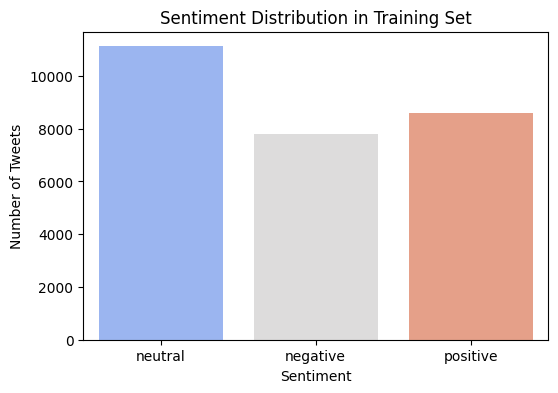

In [25]:
# Count of each sentiment and show the plot of it
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=train_df, palette='coolwarm')
plt.title('Sentiment Distribution in Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [26]:
# the percentage of the missing values 
missing_percent = train_df.isnull().mean() * 100
print(missing_percent)

textID              0.000000
text                0.003639
selected_text       0.003639
sentiment           0.000000
Time of Tweet       0.000000
Age of User         0.000000
Country             0.000000
Population -2020    0.000000
Land Area (Km²)     0.000000
Density (P/Km²)     0.000000
dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


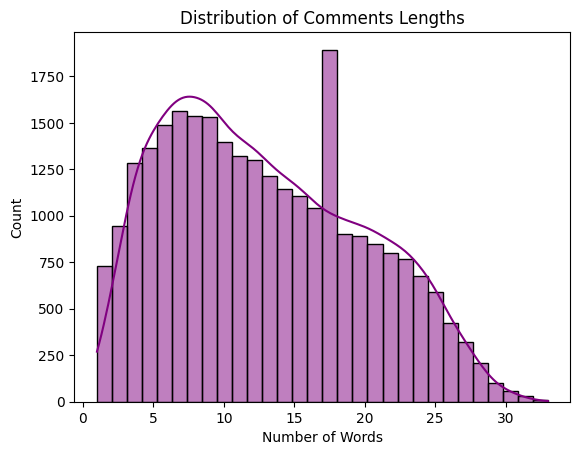

In [27]:
# to count comments length and show histogram plot 
train_df['text_length'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(train_df['text_length'], bins=30, kde=True, color='purple')
plt.title("Distribution of Comments Lengths")
plt.xlabel("Number of Words")
plt.show()

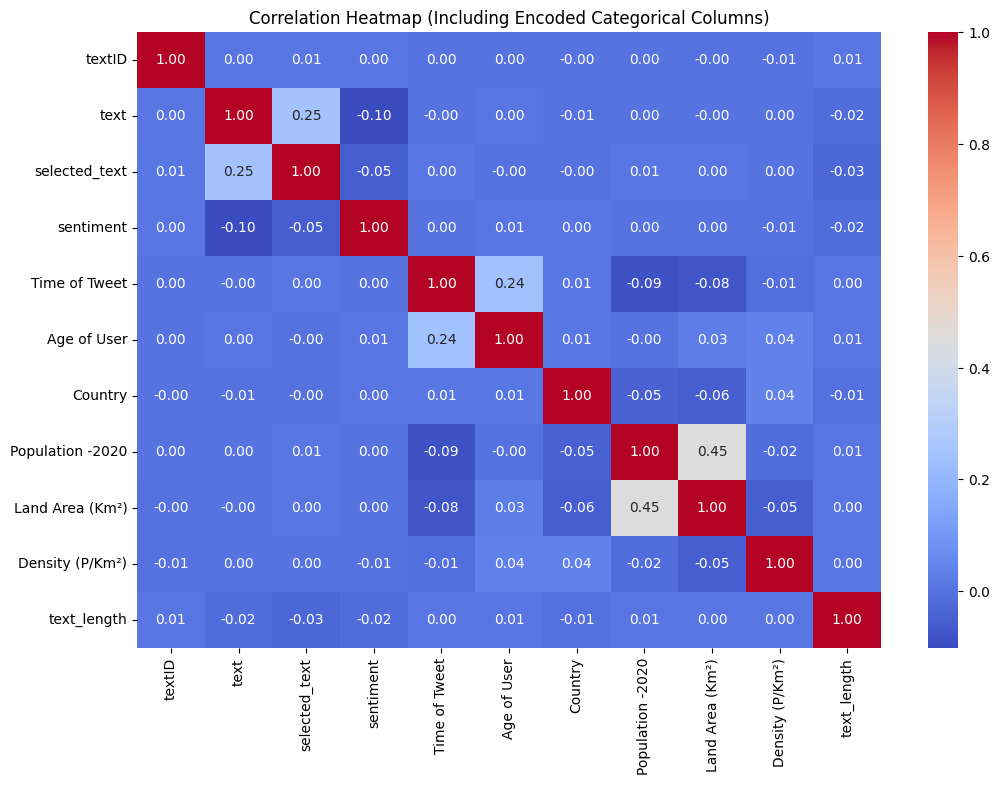

In [28]:
df_encoded = train_df.copy()

# Convert categorical columns to numeric
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# to show the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Including Encoded Categorical Columns)")
plt.show()


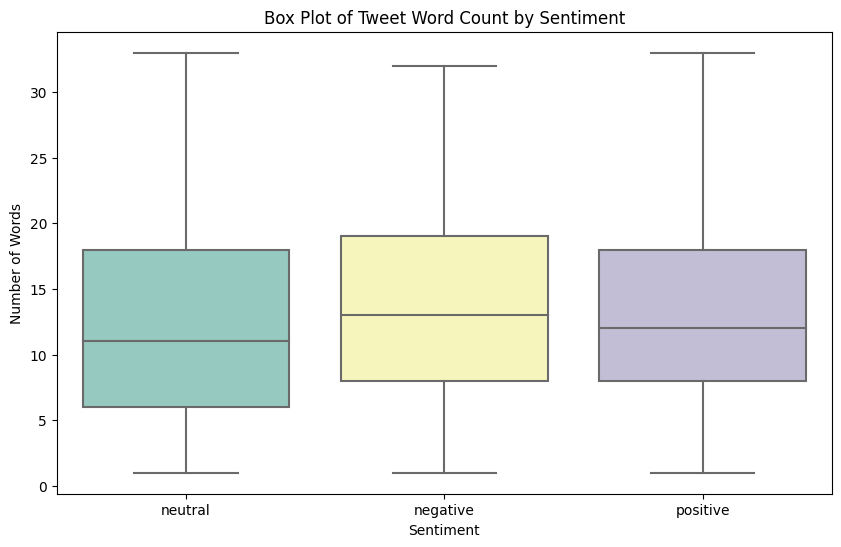

In [29]:
train_df['text_length'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))
# box-plot of word count
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='sentiment', y='text_length', palette='Set3')
plt.title('Box Plot of Tweet Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()


In [30]:
#visualization of test dataset
test_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv', encoding='ISO-8859-1')
print(test_df.shape)
test_df.head()

(4815, 9)


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


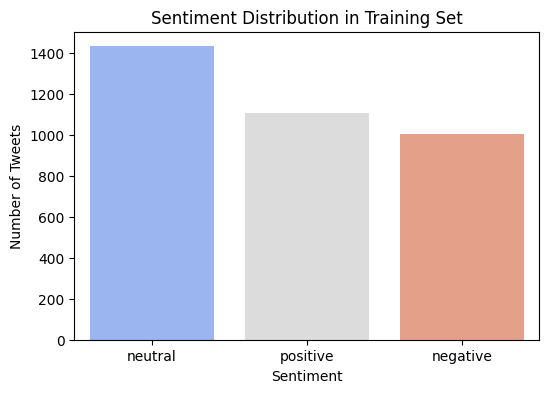

In [31]:
# Count of each sentiment
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=test_df, palette='coolwarm')
plt.title('Sentiment Distribution in Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [32]:
# the percentage of missing values
missing_percent = test_df.isnull().mean() * 100
print(missing_percent)

# to drop the row where the value of 'text' column is missing 

initial_shape = test_df.shape
test_df = test_df.dropna(subset=['text'])
final_shape = test_df.shape

print(f"\nDropped rows with missing 'text': {initial_shape[0] - final_shape[0]} rows removed.")
print(f"Remaining rows: {final_shape[0]}")

textID              26.604361
text                26.604361
sentiment           26.604361
Time of Tweet       26.604361
Age of User         26.604361
Country             26.604361
Population -2020    26.604361
Land Area (Km²)     26.604361
Density (P/Km²)     26.604361
dtype: float64

Dropped rows with missing 'text': 1281 rows removed.
Remaining rows: 3534


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


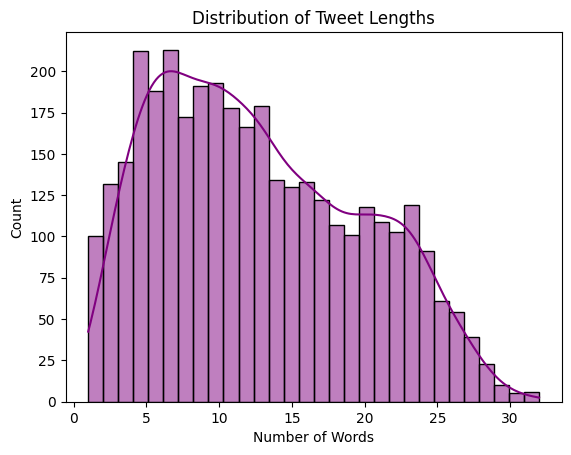

In [33]:
# to calculate the comments length and show histogram plot
test_df['text_length'] = test_df['text'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(test_df['text_length'], bins=30, kde=True, color='purple')
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.show()

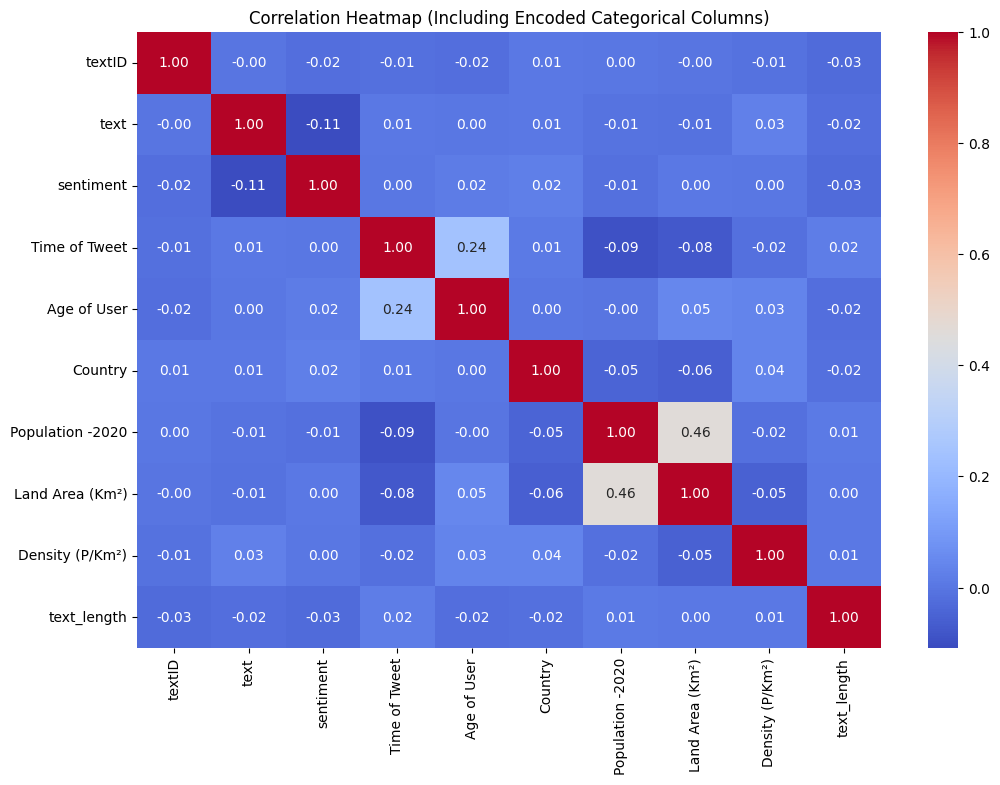

In [34]:
df_encoded = test_df.copy()

# Convert categorical columns to numeric 
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# to show the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Including Encoded Categorical Columns)")
plt.show()

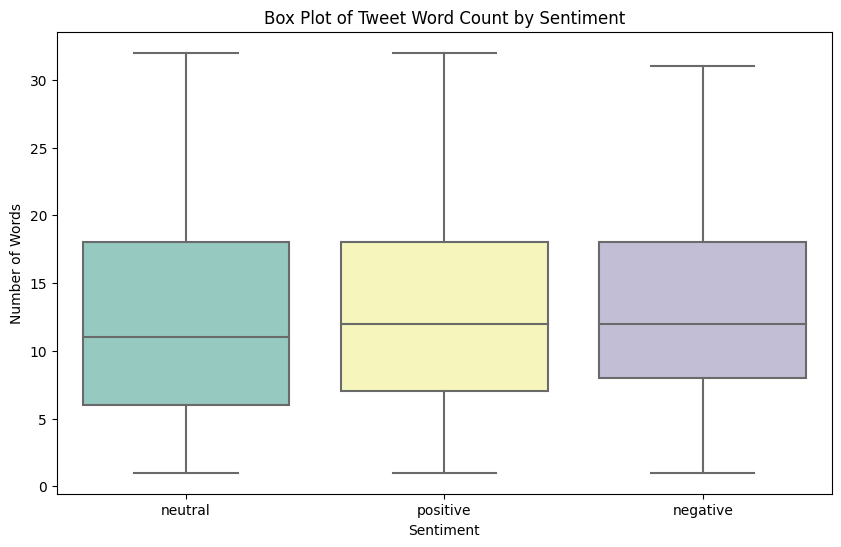

In [35]:
test_df['text_length'] = test_df['text'].astype(str).apply(lambda x: len(x.split()))

# to show the box-plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_df, x='sentiment', y='text_length', palette='Set3')
plt.title('Box Plot of Tweet Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

In [36]:
# to load and show basiclly the dataset
prepro = pd.read_csv('/kaggle/input/preprocessed-dataset-sentiment-analysis/EcoPreprocessed.csv', encoding='ISO-8859-1')
print(prepro.shape)
prepro.head()

(4084, 4)


,Unnamed: 0,review,polarity,division
0,3870,able play youtube alexa,0.5000,positive
1,62,able recognize indian accent really well drop ...,0.2794,positive
2,487,absolute smart device amazon connect external ...,0.1827,positive
3,3204,absolutely amaze new member family control hom...,0.3682,positive
4,1265,absolutely amaze previously sceptical invest m...,0.2333,positive


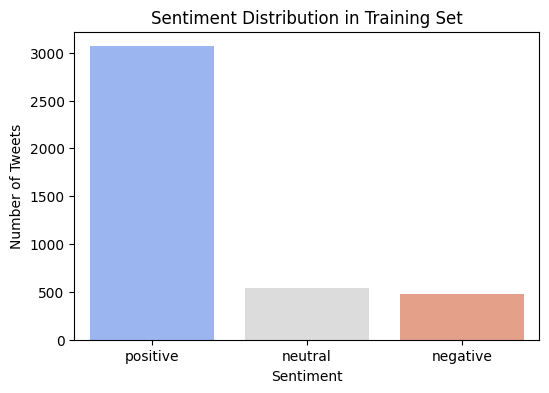

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='division', data= prepro, palette='coolwarm')
plt.title('Sentiment Distribution in Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


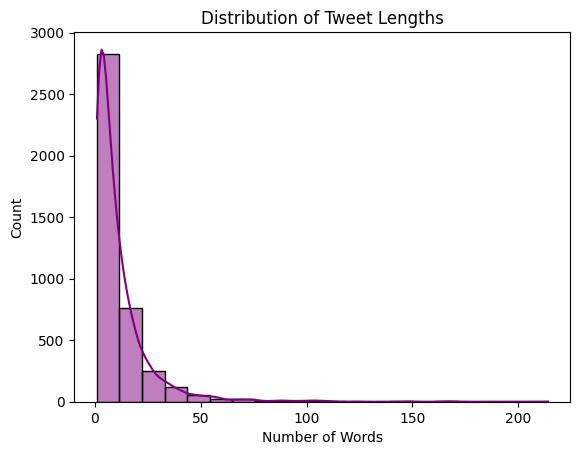

In [38]:
# to calculate the comments length and show histogram plot
prepro['text_length'] = prepro['review'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(prepro['text_length'], bins=20, kde=True, color='purple')
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.show()

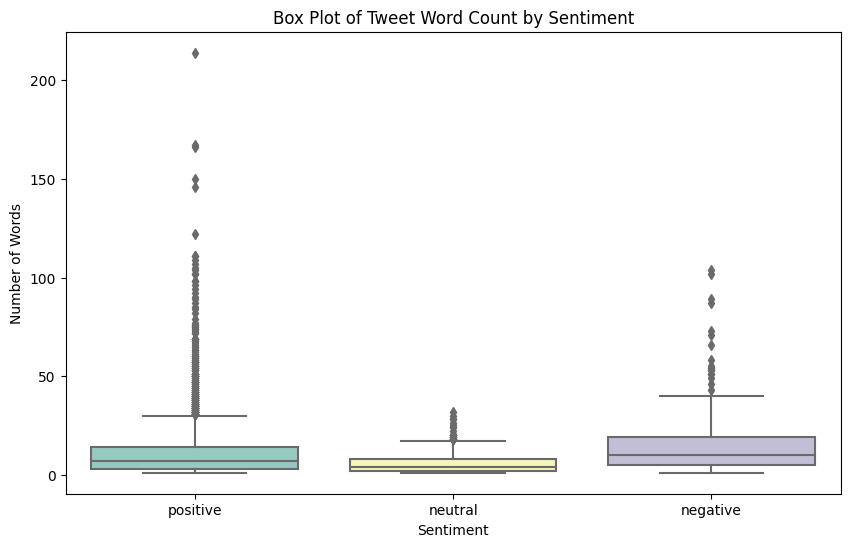

In [39]:
prepro['text_length'] = prepro['review'].astype(str).apply(lambda x: len(x.split()))
# to show the box-plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=prepro, x='division', y='text_length', palette='Set3')
plt.title('Box Plot of Tweet Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

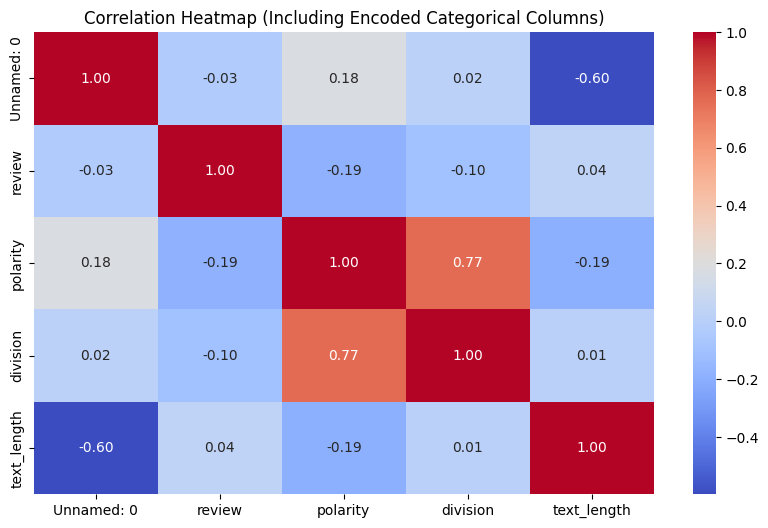

In [40]:
df_encoded = prepro.copy()
# to convert categorical columns to numerical 
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# to show the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Including Encoded Categorical Columns)")
plt.show()

In [ ]:
# ================== LOAD & BALANCE FIRST DATASET (EcoPreprocessed.csv) ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

train_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv', encoding='ISO-8859-1')
test_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv', encoding='ISO-8859-1')
# Load EcoPreprocessed.csv
prepro = pd.read_csv('/kaggle/input/preprocessed-dataset-sentiment-analysis/EcoPreprocessed.csv', encoding='ISO-8859-1')
X = prepro['review']
y = prepro['division']
df = pd.DataFrame({'review': X, 'division': y})

# Balance it by oversampling
max_count = df['division'].value_counts().max()
df_balanced = pd.concat([
    group.sample(max_count, replace=True, random_state=42)
    for _, group in df.groupby('division')
])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Rename columns
df_balanced = df_balanced.rename(columns={'review': 'text', 'division': 'sentiment'})

# Split 90% train, 10% test
from sklearn.model_selection import train_test_split
prepro_train, prepro_test = train_test_split(df_balanced, test_size=0.1, random_state=42)

# ================== COMBINE ALL TRAIN AND TEST DATA ==================
# Replace this with your original train_df and test_df if available

combined_train_df = pd.concat([train_df, prepro_train], ignore_index=True)
combined_test_df = pd.concat([test_df, prepro_test], ignore_index=True)

# Shuffle
combined_train_df = combined_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_test_df = combined_test_df.sample(frac=1, random_state=42).reset_index(drop=True)

columns_to_keep = ['text', 'sentiment']
combined_train_df = combined_train_df[columns_to_keep].dropna()
combined_test_df = combined_test_df[columns_to_keep].dropna()

print(combined_train_df.shape)
print(combined_test_df.shape)
# ================== TOKENIZATION & ENCODING ==================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(combined_train_df['text'].astype(str))
sequences = tokenizer.texts_to_sequences(combined_train_df['text'].astype(str))
X = pad_sequences(sequences, maxlen=max_len, padding='post')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(combined_train_df['sentiment'])

# Class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights_dict = dict(enumerate(class_weights))

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ================== LOAD GLOVE ==================
embedding_dim = 100
embedding_index = {}
glove_path = '/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt'
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# ================== BUILD AND TRAIN MODEL ==================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

model = Sequential([
    Embedding(max_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    Dropout(0.2),
    Bidirectional(LSTM(128)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=10,
          batch_size=64,
          callbacks=[early_stop, lr_schedule],
          class_weight=class_weights_dict)

# ================== TESTING ==================
test_sequences = tokenizer.texts_to_sequences(combined_test_df['text'].astype(str))
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)

# Evaluate
if 'sentiment' in combined_test_df.columns:
    test_eval_df = combined_test_df.dropna(subset=['sentiment']).copy()
    true_labels = label_encoder.transform(test_eval_df['sentiment'])
    pred_eval_labels = pred_classes[test_eval_df.index]

    test_accuracy = np.mean(pred_eval_labels == true_labels)
    print(f"\nTest Accuracy: {test_accuracy:.4f}")

    from sklearn.metrics import classification_report, confusion_matrix
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_eval_labels, target_names=label_encoder.classes_))

    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, pred_eval_labels))

# === Info ===
print(f"Loaded {len(embedding_index)} GloVe vectors")
print(f"Used {np.count_nonzero(np.count_nonzero(embedding_matrix, axis=1))} in embedding matrix")


(35758, 2)
(4454, 2)
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


447/447 ━━━━━━━━━━━━━━━━━━━━ 122s 258ms/step - accuracy: 0.5258 - loss: 1.0200 - val_accuracy: 0.7188 - val_loss: 0.7099 - learning_rate: 5.0000e-04
Epoch 2/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 114s 255ms/step - accuracy: 0.7108 - loss: 0.7062 - val_accuracy: 0.7578 - val_loss: 0.6193 - learning_rate: 5.0000e-04
Epoch 3/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 116s 260ms/step - accuracy: 0.7621 - loss: 0.6038 - val_accuracy: 0.7773 - val_loss: 0.5788 - learning_rate: 5.0000e-04
Epoch 4/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 114s 256ms/step - accuracy: 0.7847 - loss: 0.5513 - val_accuracy: 0.7836 - val_loss: 0.5576 - learning_rate: 5.0000e-04
Epoch 5/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 114s 255ms/step - accuracy: 0.8031 - loss: 0.5018 - val_accuracy: 0.7876 - val_loss: 0.5439 - learning_rate: 5.0000e-04
Epoch 6/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 115s 256ms/step - accuracy: 0.8182 - loss: 0.4666 - val_accuracy: 0.7894 - val_loss: 0.5448 - learning_rate: 5.0000e-04
Epoch 7/10
253/447 ━━━━━━━━━━━━━━━━━━━━ 45s 235ms/s

In [ ]:
print(combined_train_df.shape)
print(combined_test_df.shape)
print(train_df.shape)
print(test_df.shape)

In [ ]:
# === Parameters ===
max_words = 10000
max_len = 150
embedding_dim = 100

# === Load your main dataset ===
# Assume train_df and test_df are already loaded and contain 'text' and 'sentiment' columns

# === Load your balanced preprocessed dataset ===
# Change this path if needed
prepro = prepro.rename(columns={'review': 'text', 'division': 'sentiment'})

# === Sample 90% for training, 10% for testing ===
prepro_train, prepro_test = train_test_split(prepro, test_size=0.1, random_state=42)

# === Combine datasets ===
combined_train_df = pd.concat([train_df, prepro_train], ignore_index=True)
combined_test_df = pd.concat([test_df, prepro_test], ignore_index=True)

# === Tokenization ===
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(combined_train_df['text'].astype(str))
sequences = tokenizer.texts_to_sequences(combined_train_df['text'].astype(str))
X = pad_sequences(sequences, maxlen=max_len, padding='post')

# === Label Encoding ===
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(combined_train_df['sentiment'])

# === Class Weights ===
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights_dict = dict(enumerate(class_weights))

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Load GloVe embeddings ===
embedding_index = {}
glove_path = '/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt'
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Create embedding matrix
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# === Build Model ===
model = Sequential([
    Embedding(max_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    Dropout(0.2),
    Bidirectional(LSTM(128)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(len(np.unique(y)), activation='softmax')
])

# === Compile ===
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              metrics=['accuracy'])

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# === Train ===
history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=10,
          batch_size=64,
          callbacks=[early_stop, lr_schedule],
          class_weight=class_weights_dict)

# === Prepare Combined Test Data ===
test_sequences = tokenizer.texts_to_sequences(combined_test_df['text'].astype(str))
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

# === Predict ===
pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)

# === Evaluation ===
if 'sentiment' in combined_test_df.columns:
    test_eval_df = combined_test_df.dropna(subset=['sentiment']).copy()
    true_labels = label_encoder.transform(test_eval_df['sentiment'])
    pred_eval_labels = pred_classes[test_eval_df.index]

    test_accuracy = np.mean(pred_eval_labels == true_labels)
    print(f"\nTest Accuracy: {test_accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(true_labels, pred_eval_labels, target_names=label_encoder.classes_))

    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, pred_eval_labels))

print(f"Loaded {len(embedding_index)} GloVe vectors")
print(f"Used {np.count_nonzero(np.count_nonzero(embedding_matrix, axis=1))} in embedding matrix")


In [ ]:
def clean_text(text):
    """Universal text cleaning function for all datasets"""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)      # Remove mentions
    text = re.sub(r'#\w+', '', text)      # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)   # Remove punctuation
    return text.strip()


# Process third dataset
train_df = train_df.rename(columns={'text': 'text', 'sentiment': 'sentiment'})
train_df['text'] = train_df['text'].apply(clean_text)
train_df.dropna(subset=['text', 'sentiment'], inplace=True)
train_df = train_df[['text', 'sentiment']]
# Clean column names and remove duplicates
train_df.columns = train_df.columns.str.strip()
train_df = train_df.loc[:, ~train_df.columns.duplicated()]

# Process third dataset
test_df = test_df.rename(columns={'text': 'text', 'sentiment': 'sentiment'})
test_df['text'] = test_df['text'].apply(clean_text)
test_df.dropna(subset=['text', 'sentiment'], inplace=True)
test_df = test_df[['text', 'sentiment']]
# Clean column names and remove duplicates
test_df.columns = test_df.columns.str.strip()
test_df = test_df.loc[:, ~test_df.columns.duplicated()]

# Process second dataset
prepro = prepro.rename(columns={'review': 'text', 'polarity': 'sentiment'})
prepro['text'] = prepro['text'].apply(clean_text)
prepro.dropna(subset=['text', 'sentiment'], inplace=True)
prepro = prepro[['text', 'sentiment']]
# Clean column names and remove duplicates
prepro.columns = prepro.columns.str.strip()
prepro = prepro.loc[:, ~prepro.columns.duplicated()]

# ----------------------
# 2. Dataset Combination (FIXED)
# ----------------------

columns_to_keep = ['text', 'sentiment']
train_df = train_df[columns_to_keep].dropna()
train_df = train_df[columns_to_keep].dropna()
test_df = test_df[columns_to_keep].dropna()
test_df = test_df[columns_to_keep].dropna()
prepro = prepro[columns_to_keep].dropna()

# Verify all datasets have clean columns
print("Columns before concatenation:")
print("Train:", train_df.columns.tolist())
print("Test:", test_df.columns.tolist())
print("Prepro:", prepro.columns.tolist())


# Ensure no duplicate columns exist
for df in [train_df, test_df, prepro]:
    df.columns = df.columns.str.strip()  # Remove whitespace in column names
    df = df.loc[:, ~df.columns.duplicated()]

# Combine all datasets
combined_df = pd.concat([train_df, prepro, test_df], ignore_index=True)

# Final check for non-string sentiment values
print("Unique sentiment types:", combined_df['sentiment'].apply(type).unique())

# Remove any residual NaN/float values
combined_df = combined_df[combined_df['sentiment'].apply(lambda x: isinstance(x, str))]
combined_df = combined_df.dropna(subset=['sentiment'])

# Split into train/test
combined_train_df, combined_test_df = train_test_split(combined_df, test_size=0.2, random_state=42, stratify=combined_df['sentiment'])

max_words = 10000
max_len = 150
embedding_dim = 100

# === Sample 90% for training, 10% for testing ===
#prepro_train, prepro_test = train_test_split(prepro, test_size=0.1, random_state=42)

# === Combine datasets ===
#combined_train_df = pd.concat([train_df, prepro_train], ignore_index=True)
#combined_test_df = pd.concat([test_df, prepro_test], ignore_index=True)

# === Tokenization ===
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(combined_train_df['text'].astype(str))
sequences = tokenizer.texts_to_sequences(combined_train_df['text'].astype(str))
X = pad_sequences(sequences, maxlen=max_len, padding='post')

# === Label Encoding ===
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(combined_train_df['sentiment'])

# === Class Weights ===
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights_dict = dict(enumerate(class_weights))

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Load GloVe embeddings ===
embedding_index = {}
glove_path = '/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt'
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Create embedding matrix
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# === Build Model ===
model = Sequential([
    Embedding(max_words, embedding_dim, weights=[embedding_matrix], trainable=True),
    Dropout(0.2),
    Bidirectional(LSTM(256)),
    Dropout(0.2),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(len(np.unique(y)), activation='softmax')
])

# === Compile ===
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              metrics=['accuracy'])

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# === Train ===
history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=20,
          batch_size=128,
          callbacks=[early_stop, lr_schedule],
          class_weight=class_weights_dict)

# === Prepare Combined Test Data ===
test_sequences = tokenizer.texts_to_sequences(combined_test_df['text'].astype(str))
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

# === Predict ===
pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)

# === Evaluation ===
final_train_accuracy = history.history['accuracy'][-1]
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")

if 'sentiment' in combined_test_df.columns:
    test_eval_df = combined_test_df.dropna(subset=['sentiment']).copy().reset_index(drop=True)
    true_labels = label_encoder.transform(test_eval_df['sentiment'])

    pred_eval_labels = pred_classes[:len(test_eval_df)]

    test_accuracy = np.mean(pred_eval_labels == true_labels)
    print(f"\nTest Accuracy: {test_accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(true_labels, pred_eval_labels, target_names=label_encoder.classes_))

    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, pred_eval_labels))


print(f"Loaded {len(embedding_index)} GloVe vectors")
print(f"Used {np.count_nonzero(np.count_nonzero(embedding_matrix, axis=1))} in embedding matrix")

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Analyze dataset size and vocabulary ---
total_train_samples = len(combined_train_df)
total_test_samples = len(combined_test_df)

# Total words the tokenizer found in your full train dataset
total_words_in_vocab = len(tokenizer.word_index)

# Words actually used in the model (limited by num_words=max_words)
actual_words_used = min(len(tokenizer.word_index), max_words)

# Print results
print("Total train samples:", total_train_samples)
print("Total test samples:", total_test_samples)
print("Total unique words in dataset (tokenizer.word_index):", total_words_in_vocab)
print("Number of words actually used (due to max_words limit):", actual_words_used)


In [ ]:
user_text = input("Enter a text to classify its sentiment: ")

user_seq = tokenizer.texts_to_sequences([user_text])
user_pad = pad_sequences(user_seq, maxlen=max_len, padding='post')

user_pred_probs = model.predict(user_pad)
user_pred_class = np.argmax(user_pred_probs, axis=1)[0]

user_pred_label = label_encoder.inverse_transform([user_pred_class])[0]
print(f"Predicted sentiment: {user_pred_label}")
